In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))


# Chapter 6 — Ensemble Learning Techniques
## Lesson 8: Out-of-Bag (OOB) Estimation and When It Works

> **Goal:** Understand *what* Out-of-Bag (OOB) estimation is, *why* it is surprisingly accurate for bagging-style ensembles, *how* to use it correctly in practice, and *when* you should **not** trust it.



### What you will learn

By the end of this lesson you should be able to:

- Derive the classic bootstrap fact that a training point is OOB with probability about $e^{-1} \approx 0.368$ for each bootstrap replicate.
- Define OOB predictors and the OOB risk estimator for **classification** and **regression**.
- Explain the statistical intuition: why OOB behaves like an “internal cross-validation” for bagging and random forests.
- Compute OOB metrics in scikit-learn (accuracy, ROC-AUC, log-loss, $R^2$, RMSE) and compare them to $k$-fold CV.
- Diagnose failure modes: **time series**, **group leakage**, **distribution shift**, **target leakage**, and **highly dependent samples**.
- Use OOB curves for engineering decisions (number of trees / early stopping) while avoiding selection bias.



### Setup

We will use multiple datasets (classification + regression) from your repository to demonstrate that OOB is a *general* idea, not tied to a single dataset.

Datasets we will randomly use in this lesson:

- `../../../Datasets/Classification/diabetes.csv` (binary classification)
- `../../../Datasets/Classification/Wine_Quality.csv` (classification via thresholding)
- `../../../Datasets/Regression/diamonds.csv` (regression)
- `../../../Datasets/Regression/listings.csv` (regression with **group leakage** via `host_id`)

All file paths are **relative to this notebook location** (as you requested).



In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, TimeSeriesSplit, GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


## 1) Bagging, bootstrap samples, and the OOB idea

### 1.1 Bootstrap recap (why bagging exists)

Bagging (bootstrap aggregating) forms an ensemble by repeatedly sampling (with replacement) from the training set.

Let the training set be $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$.  
For $b = 1,\dots,B$, draw a bootstrap dataset

$$
\mathcal{D}^{(b)} = \{(x_{i_k}, y_{i_k})\}_{k=1}^n,
$$

where each index $i_k$ is drawn uniformly from $\{1,\dots,n\}$ **with replacement**.

Train a base learner $f^{(b)}$ on $\mathcal{D}^{(b)}$. The bagged predictor is the aggregate

- **Regression (mean):**
$$
\hat f_{\text{bag}}(x) = \frac{1}{B} \sum_{b=1}^B f^{(b)}(x).
$$

- **Classification (majority vote or probability averaging):**
$$
\hat p_{\text{bag}}(y=k \mid x) = \frac{1}{B} \sum_{b=1}^B p^{(b)}(y=k \mid x).
$$

Bagging reduces variance because the bootstrap learners are *different* (even if the base learner is unstable like a deep tree).

### 1.2 Which points are “left out” by a bootstrap draw?

In bootstrap sampling, we draw $n$ times **with replacement** from $n$ points. Some points appear multiple times, and some points do **not** appear at all.

A point $i$ is **out-of-bag** (OOB) for bootstrap replicate $b$ if it is absent from $\mathcal{D}^{(b)}$.

That means: OOB points play the role of “validation” points *for that bootstrap-trained model*.

So for each training example $x_i$, we can evaluate it only using the subset of trees that never saw $x_i$ during training.

That gives an estimate of generalization performance **without making a separate validation split**.



## 2) The $e^{-1}$ fact: probability a point is OOB

Fix a training index $i$. In one bootstrap replicate, we draw $n$ indices with replacement.  
The probability that a *single* draw is *not* $i$ is $1 - \frac{1}{n}$.

Because draws are independent,

$$
\Pr(i \text{ is never selected}) = \left(1 - \frac{1}{n}\right)^n.
$$

As $n \to \infty$,

$$
\left(1 - \frac{1}{n}\right)^n \to e^{-1} \approx 0.367879.
$$

So roughly **36.8%** of training points are OOB for any given bootstrap sample.

Equivalently, about **63.2%** of the training set appears in a bootstrap sample (counting unique points).  
This is the origin of the “.632 bootstrap” terminology.

### Expected number of OOB votes per sample

Let $B$ be the number of trees. For a fixed point $i$, define indicator variables

$$
Z_b(i) = \mathbb{1}[i \text{ is OOB for tree } b].
$$

Then $\mathbb{E}[Z_b(i)] \approx e^{-1}$.  
So the expected number of trees that can vote for sample $i$ is

$$
\mathbb{E}\left[\sum_{b=1}^B Z_b(i)\right] = B \cdot \mathbb{E}[Z_b(i)] \approx 0.368B.
$$

Practical implication:
- with $B=100$ trees, each sample gets about **37 OOB predictions** on average.
- with small $B$ (e.g., $B=10$), OOB estimates can be noisy because each sample gets only ~3–4 OOB votes.



## 3) OOB predictor and OOB risk estimator

### 3.1 OOB predictor for a single training point

For training point $i$, define the set of trees that did **not** include $i$ in their bootstrap sample:

$$
\mathcal{B}_{-i} = \{ b \in \{1,\dots,B\} : i \notin \mathcal{D}^{(b)} \}.
$$

Define the OOB prediction for $x_i$ as the aggregation over only those trees:

- **Regression:**
$$
\hat f^{-i}(x_i) = \frac{1}{|\mathcal{B}_{-i}|} \sum_{b \in \mathcal{B}_{-i}} f^{(b)}(x_i).
$$

- **Classification (probability averaging):**
$$
\hat p^{-i}(y=k \mid x_i) = \frac{1}{|\mathcal{B}_{-i}|} \sum_{b \in \mathcal{B}_{-i}} p^{(b)}(y=k \mid x_i).
$$

### 3.2 OOB risk estimator (general form)

Let $\ell(y, \hat y)$ be a loss function (0-1 loss, log-loss, squared error, etc.).  
The OOB estimate of risk is

$$
\widehat{R}_{\text{OOB}} = \frac{1}{n} \sum_{i=1}^n \ell\big(y_i, \hat f^{-i}(x_i)\big).
$$

This resembles leave-one-out (LOO) cross-validation, but is cheaper for bagging because the OOB predictions come “for free” from the bootstrap procedure.

### 3.3 Why OOB is often close to test performance

High-level intuition:

- For each $i$, the OOB predictor $\hat f^{-i}$ is trained on about $0.632n$ unique points (slightly fewer than $n$).
- It evaluates on a point that was not used for training that particular subset of trees.
- Averaging across many trees smooths variance, so the OOB estimate is stable.

Under i.i.d. sampling and sufficiently many trees, OOB is typically a good proxy for generalization error.

But it is **not magic**: OOB inherits the same assumptions as bagging (especially independence / exchangeability of samples).



## 4) When is OOB *statistically* valid? (assumptions and bias/variance intuition)

OOB is fundamentally an **internal resampling-based** estimate of prediction error. Its credibility depends on whether the “left-out” points behave like *fresh* draws from the same data-generating process.

### 4.1 Exchangeability and i.i.d. sampling

A standard sufficient condition is that the dataset is i.i.d.:

$$
(x_i, y_i) \overset{\text{i.i.d.}}{\sim} P,
$$

and that the learning algorithm uses only the data points (no future leakage, no shared identifiers that encode the label, etc.).

If samples are i.i.d., leaving out some points gives a valid proxy for out-of-sample error.

If samples are **dependent** (time series, repeated measures, multiple rows per entity, spatial correlation), then leaving out a row does **not** necessarily create an “unseen” example; it may still be extremely similar to training rows, making OOB overly optimistic.

### 4.2 Why OOB can be slightly biased

A subtle point: for sample $i$, the OOB ensemble uses only trees trained on bootstrap datasets that exclude $i$.
But those trees are trained on bootstrap datasets of size $n$ (with duplicates), which contain about $0.632n$ unique points.

So the “training set size” of the OOB predictor is effectively smaller than the training set size of the final model trained on all $n$ points.

This creates a bias:

- If performance improves substantially with more data, then OOB (trained on fewer unique points) can be **pessimistic** relative to the final model.
- On the other hand, because bootstrap sampling introduces duplicates and some regularization-like effects, OOB may also behave differently from a clean train/test split.

In practice for random forests with enough trees, OOB tends to be close to test performance, but not guaranteed.

### 4.3 Variance of OOB and the number of trees

Let $N_i = |\mathcal{B}_{-i}|$ be the number of OOB trees for sample $i$.
We argued $\mathbb{E}[N_i] \approx 0.368B$.

The OOB prediction is an average over $N_i$ random variables (tree predictions). If tree predictions have variance $\sigma^2$ and weak correlation, then (very roughly)

$$
\mathrm{Var}(\hat f^{-i}(x_i)) \approx \frac{\sigma^2}{N_i} + \text{correlation terms}.
$$

So increasing $B$ reduces OOB noise. This is why OOB curves vs number of trees stabilize after a while.

### 4.4 OOB and model selection: a caution

It is tempting to tune hyperparameters by maximizing OOB score.
But if you search over many hyperparameter configurations and pick the best OOB score, you incur **selection bias** (optimism).

This is the same problem as using the validation set multiple times. The fix is the same:

- Use a separate test set, or
- Use nested CV, or
- Use a final “locked” evaluation after tuning.

We will demonstrate this practical issue later.



In [3]:
from pathlib import Path

def load_csv(rel_path: str, **read_csv_kwargs) -> pd.DataFrame:
    """Load a CSV using a repo-relative path. Raises with a helpful message if missing."""
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(
            f"Could not find {rel_path}.\n"
            "Make sure you run this notebook from the repository structure you described."
        )
    return pd.read_csv(p, **read_csv_kwargs)

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 5) Example 1 — OOB for classification (diabetes.csv)

We start with a clean binary classification dataset.

**What we will do:**
1. Load `diabetes.csv`.
2. Train a `RandomForestClassifier` with `oob_score=True`.
3. Compare OOB accuracy to 5-fold stratified CV accuracy.
4. Use `warm_start=True` to plot **OOB error vs number of trees**.

Key point:
- The OOB score is computed using only out-of-bag predictions for each sample.
- In scikit-learn, for classification, the OOB class probabilities are stored in `oob_decision_function_`.



In [4]:
df = load_csv("../../../Datasets/Classification/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


In [5]:
# Separate features/target
target_col = "classification"
X = df.drop(columns=[target_col])
y = df[target_col]

# Sanity checks
print("Shape:", X.shape)
print("Class balance:\n", y.value_counts(normalize=True).rename("proportion"))


Shape: (768, 8)
Class balance:
 classification
Non-Diabetic    0.651042
Diabetic        0.348958
Name: proportion, dtype: float64


In [6]:
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    oob_score=True,
    n_jobs=-1,
    bootstrap=True,
)

rf.fit(X, y)

print("OOB accuracy (built-in):", rf.oob_score_)


OOB accuracy (built-in): 0.7630208333333334


In [7]:
# Compute additional OOB metrics from oob_decision_function_
proba_oob = rf.oob_decision_function_
classes = rf.classes_

# Map y to integer indices
y_index = pd.Series(y).map({c:i for i,c in enumerate(classes)}).to_numpy()

# OOB log loss and ROC-AUC (binary)
oob_logloss = log_loss(y_index, proba_oob, labels=np.arange(len(classes)))

if len(classes) == 2:
    oob_auc = roc_auc_score(y_index, proba_oob[:, 1])
    print("OOB log-loss:", oob_logloss)
    print("OOB ROC-AUC:", oob_auc)
else:
    print("OOB log-loss:", oob_logloss)


OOB log-loss: 0.4866994629495425
OOB ROC-AUC: 0.8225111940298508


In [8]:
# Compare with 5-fold stratified CV accuracy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    X, y, cv=cv, scoring="accuracy", n_jobs=-1
)

print("CV accuracy mean:", cv_scores.mean())
print("CV accuracy std :", cv_scores.std())


CV accuracy mean: 0.7655547067311773
CV accuracy std : 0.02328467767374559


### 5.1 OOB error curve vs number of trees

OOB enables a practical engineering trick:
- Start with a small number of trees.
- Add trees incrementally (`warm_start=True`).
- Track OOB error until it stabilizes.

This gives a cheap way to select a reasonable `n_estimators` without a separate validation set.



C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


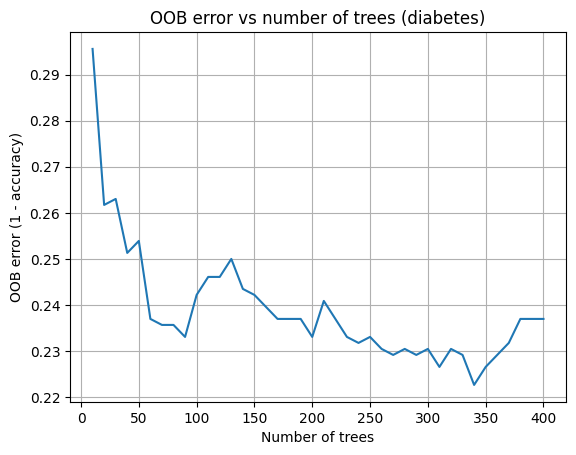

Last OOB accuracy: 0.7630208333333334


In [9]:
rf_ws = RandomForestClassifier(
    n_estimators=10,
    warm_start=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

n_estimators_list = list(range(10, 401, 10))
oob_error = []

for n in n_estimators_list:
    rf_ws.set_params(n_estimators=n)
    rf_ws.fit(X, y)
    oob_error.append(1 - rf_ws.oob_score_)

plt.figure()
plt.plot(n_estimators_list, oob_error)
plt.xlabel("Number of trees")
plt.ylabel("OOB error (1 - accuracy)")
plt.title("OOB error vs number of trees (diabetes)")
plt.grid(True)
plt.show()

print("Last OOB accuracy:", 1 - oob_error[-1])


## 6) Manual OOB computation (to fully understand what scikit-learn does)

It is useful to compute OOB predictions manually once, because it clarifies:

- Every training point has a *different* number of OOB trees.
- Some points can have **zero** OOB predictions if `B` is too small (rare when `B` is large).
- The OOB prediction aggregates only trees where the point is excluded from the bootstrap sample.

Below we:
1. Fit a random forest.
2. For each tree, recover which samples were in its bootstrap set (via `estimators_samples_` in scikit-learn).
3. Accumulate predicted probabilities for OOB samples.
4. Normalize and compute accuracy/log-loss.



Manual OOB accuracy: 0.7643229166666666
Manual OOB log-loss: 0.48625037564533696
Built-in OOB accuracy: 0.7643229166666666
Fraction of samples with at least 1 OOB vote: 1.0


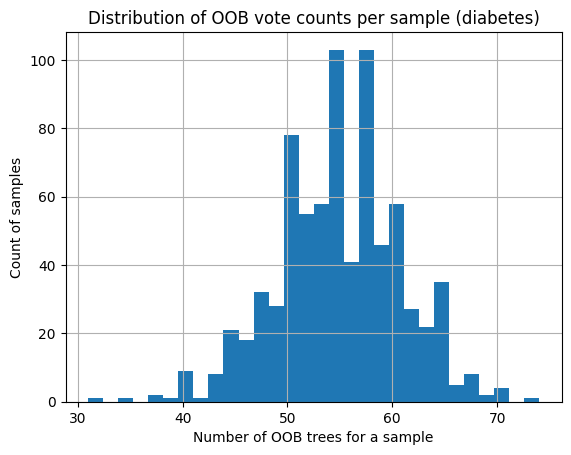

In [10]:
rf_small = RandomForestClassifier(
    n_estimators=150,
    random_state=123,
    n_jobs=-1,
    bootstrap=True,
    oob_score=True
)
rf_small.fit(X, y)

# Manual OOB aggregation
n = X.shape[0]
n_classes = len(rf_small.classes_)
sum_proba = np.zeros((n, n_classes), dtype=float)
counts = np.zeros(n, dtype=int)

X_np = X.to_numpy()

for tree, sample_idx in zip(rf_small.estimators_, rf_small.estimators_samples_):
    inbag = np.zeros(n, dtype=bool)
    inbag[sample_idx] = True
    oob_mask = ~inbag
    
    if not np.any(oob_mask):
        continue
    
    proba = tree.predict_proba(X_np[oob_mask])
    sum_proba[oob_mask] += proba
    counts[oob_mask] += 1

# Avoid division by zero (should be very rare with enough trees)
valid = counts > 0
proba_oob_manual = np.zeros_like(sum_proba)
proba_oob_manual[valid] = sum_proba[valid] / counts[valid, None]

# Predictions
pred_manual = rf_small.classes_[np.argmax(proba_oob_manual[valid], axis=1)]
y_valid = y.to_numpy()[valid]

acc_manual = accuracy_score(y_valid, pred_manual)

y_idx_valid = pd.Series(y_valid).map({c:i for i,c in enumerate(rf_small.classes_)}).to_numpy()
ll_manual = log_loss(y_idx_valid, proba_oob_manual[valid], labels=np.arange(n_classes))

print("Manual OOB accuracy:", acc_manual)
print("Manual OOB log-loss:", ll_manual)
print("Built-in OOB accuracy:", rf_small.oob_score_)
print("Fraction of samples with at least 1 OOB vote:", valid.mean())

plt.figure()
plt.hist(counts[valid], bins=30)
plt.xlabel("Number of OOB trees for a sample")
plt.ylabel("Count of samples")
plt.title("Distribution of OOB vote counts per sample (diabetes)")
plt.grid(True)
plt.show()


## 7) Example 2 — OOB probabilities and calibration intuition (Wine_Quality.csv)

The wine quality dataset is often used for regression, but here we create a binary label:

- Positive class: `quality >= 7`
- Negative class: `quality <= 6`

This produces a more imbalanced classification task, which helps us discuss when OOB can be noisy (especially with minority classes).

We compute:
- OOB accuracy
- OOB ROC-AUC
- OOB log-loss

Then we compare with stratified CV.



In [11]:
wine = load_csv("../../../Datasets/Classification/Wine_Quality.csv")
wine.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [12]:
# Create binary target
y_wine = (wine["quality"] >= 7).astype(int)
X_wine = wine.drop(columns=["quality"])

print("Shape:", X_wine.shape)
print("Positive rate:", y_wine.mean())


Shape: (4898, 11)
Positive rate: 0.21641486320947326


In [13]:
rf_wine = RandomForestClassifier(
    n_estimators=600,
    random_state=7,
    n_jobs=-1,
    oob_score=True
)
rf_wine.fit(X_wine, y_wine)

proba_oob = rf_wine.oob_decision_function_
oob_acc = rf_wine.oob_score_
oob_auc = roc_auc_score(y_wine, proba_oob[:, 1])
oob_ll = log_loss(y_wine, proba_oob[:, 1])

print("OOB accuracy:", oob_acc)
print("OOB ROC-AUC :", oob_auc)
print("OOB log-loss:", oob_ll)


OOB accuracy: 0.8944467129440588
OOB ROC-AUC : 0.931814673522963
OOB log-loss: 0.27311762090622527


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
cv_acc = cross_val_score(
    RandomForestClassifier(n_estimators=600, random_state=7, n_jobs=-1),
    X_wine, y_wine, cv=cv, scoring="accuracy", n_jobs=-1
)
cv_auc = cross_val_score(
    RandomForestClassifier(n_estimators=600, random_state=7, n_jobs=-1),
    X_wine, y_wine, cv=cv, scoring="roc_auc", n_jobs=-1
)

print("CV accuracy mean:", cv_acc.mean(), "std:", cv_acc.std())
print("CV ROC-AUC mean :", cv_auc.mean(), "std:", cv_auc.std())


CV accuracy mean: 0.8811769610806529 std: 0.012680309268614564
CV ROC-AUC mean : 0.9182487687046956 std: 0.005933501853902403


### 7.1 Note on class imbalance and OOB

In imbalanced settings, OOB still works, but you should watch for two practical issues:

1. **Minority class scarcity in OOB predictions**:  
   Even if each sample has ~0.368B OOB trees, the *distribution of class labels* can make metrics like ROC-AUC unstable for small datasets.

2. **Threshold dependence**:  
   Accuracy depends on a fixed decision threshold. Using ROC-AUC or log-loss (proper scoring rules) is often more informative when probability estimates matter.

If you need reliable probability calibration, you typically combine OOB with calibration methods (Platt scaling / isotonic), but calibration itself needs proper validation (often cross-validation), because calibrating on the same data can overfit.



## 8) Example 3 — OOB for regression (diamonds.csv)

For regression, scikit-learn exposes:

- `oob_prediction_` (OOB predicted target for each training sample)
- `oob_score_` (default: $R^2$)

We compute:
- OOB $R^2$
- OOB RMSE

and compare with 5-fold CV.



In [15]:
diamonds = load_csv("../../../Datasets/Regression/diamonds.csv")
diamonds.head()


,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [16]:
# Target is "price" (typical for diamonds dataset)
y_d = diamonds["price"]
X_d = diamonds.drop(columns=["price"])

# We'll use a simple preprocessing pipeline because there are categorical features.
num_cols = X_d.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_d.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

rf_reg = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

model = Pipeline([
    ("prep", preprocess),
    ("rf", rf_reg)
])


In [17]:
model.fit(X_d, y_d)

# Extract OOB predictions from the underlying regressor
rf_fitted = model.named_steps["rf"]
y_oob_pred = rf_fitted.oob_prediction_

oob_r2 = rf_fitted.oob_score_
oob_rmse = rmse(y_d, y_oob_pred)

print("OOB R^2 :", oob_r2)
print("OOB RMSE:", oob_rmse)


OOB R^2 : 0.999959318126791
OOB RMSE: 25.445345637604877


In [18]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# R^2
cv_r2 = cross_val_score(model, X_d, y_d, cv=cv, scoring="r2", n_jobs=-1)
print("CV R^2 mean:", cv_r2.mean(), "std:", cv_r2.std())

# RMSE via manual loop (since 'neg_root_mean_squared_error' exists, but we'll keep it explicit)
rmses = []
for train_idx, test_idx in cv.split(X_d):
    X_tr, X_te = X_d.iloc[train_idx], X_d.iloc[test_idx]
    y_tr, y_te = y_d.iloc[train_idx], y_d.iloc[test_idx]
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmses.append(rmse(y_te, pred))

print("CV RMSE mean:", np.mean(rmses), "std:", np.std(rmses))


CV R^2 mean: 0.9999449894726669 std: 1.326357823510936e-05
CV RMSE mean: 29.3446094832075 std: 3.622179902245773


## 9) Hyperparameter tuning with OOB (useful, but beware selection bias)

OOB can be used to compare hyperparameters quickly, especially for:

- `max_features` (feature subsampling)
- `min_samples_leaf`
- `max_depth`
- `bootstrap` vs not

However, if you search over many hyperparameter settings and choose the best OOB score, your chosen score is *optimistic*.

We demonstrate this with a small grid on the diabetes dataset:
- We'll compute OOB accuracy for each configuration.
- We'll also compute a **held-out test accuracy** to see how much OOB overestimates when used for selection.



In [19]:
# Hold out a final test set (locked evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=123
)

grid = [
    {"max_features": "sqrt", "min_samples_leaf": 1},
    {"max_features": "sqrt", "min_samples_leaf": 5},
    {"max_features": "log2", "min_samples_leaf": 1},
    {"max_features": "log2", "min_samples_leaf": 5},
    {"max_features": None, "min_samples_leaf": 1},
    {"max_features": None, "min_samples_leaf": 5},
]

rows = []
for params in grid:
    rf = RandomForestClassifier(
        n_estimators=400,
        random_state=0,
        n_jobs=-1,
        oob_score=True,
        **params
    )
    rf.fit(X_train, y_train)
    oob = rf.oob_score_
    test = rf.score(X_test, y_test)
    rows.append({**params, "oob_accuracy": oob, "test_accuracy": test})

res = pd.DataFrame(rows).sort_values("oob_accuracy", ascending=False)
res


,max_features,min_samples_leaf,oob_accuracy,test_accuracy
0,sqrt,1,0.767361,0.744792
5,None,5,0.767361,0.750000
1,sqrt,5,0.765625,0.755208
3,log2,5,0.765625,0.755208
2,log2,1,0.763889,0.750000
4,None,1,0.758681,0.760417


### Interpretation

If the configuration with the best OOB accuracy also has the best test accuracy, selection bias is small.
But if the best OOB choice underperforms on the test set, you observed a form of “validation overfitting”.

Rule of thumb:
- OOB is good for quick iteration.
- For publication-grade or business-critical evaluation, lock a test set or use nested CV.



## 10) When does OOB work well? When does it fail?

### 10.1 OOB works well when

1. **Samples are i.i.d. (exchangeable)**: no temporal ordering dependence, no duplicated entities, no repeated measures per entity without proper grouping.
2. **Bootstrap makes sense**: the bootstrap samples approximate the training distribution.
3. **You have enough trees**: each point needs enough OOB votes (typically $B \ge 200$ is safe for many tabular problems).
4. **No leakage**: features do not encode the label via future information, IDs, or post-outcome variables.
5. **Stationarity**: the train and test come from the same distribution (no major covariate shift).

### 10.2 OOB can fail (or mislead) when

1. **Time series / temporal dependence**: leaving out a time point does not represent “future” generalization. OOB can be overly optimistic.
2. **Grouped data / repeated entities**: if multiple rows share an entity (user, host, patient), OOB will train on some rows of that entity and validate on other rows—leakage via identity.
3. **Data drift / nonstationarity**: OOB estimates in-sample generalization, not future drift performance.
4. **Very small datasets**: OOB vote counts per sample are too low; OOB becomes high variance.
5. **Aggressive hyperparameter search**: OOB used for model selection yields optimistic scores unless you keep a separate test set.

We will demonstrate (1) and (2) with short experiments.



## 11) Demonstration — OOB is not a substitute for time-series validation

We construct a simple synthetic time series where adjacent samples are correlated.
Then we compare:

- OOB score (random forest trained on all points, OOB predicted)
- TimeSeriesSplit CV score (forward-chaining)

In many time-series settings, the correct question is: *how well do we predict the future from the past?*  
OOB does not enforce that directionality.



In [20]:
rng = np.random.default_rng(0)

n = 1500
t = np.arange(n)

# Autocorrelated feature + drift
x1 = np.sin(t / 25.0) + 0.2 * rng.normal(size=n)
x2 = np.cumsum(rng.normal(size=n)) / 50.0  # random walk -> strong dependence
X_ts = pd.DataFrame({"x1": x1, "x2": x2})

# Target depends on the *future* trend direction (harder and non-stationary)
y_ts = (np.roll(x2, -5) > x2).astype(int)  # label uses future information by construction
y_ts[-5:] = y_ts[-6]  # fix tail

# OOB evaluation (incorrect for this scenario)
rf_ts = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1, oob_score=True)
rf_ts.fit(X_ts, y_ts)
oob_acc = rf_ts.oob_score_

# Proper time-series CV
tscv = TimeSeriesSplit(n_splits=5)
accs = []
for train_idx, test_idx in tscv.split(X_ts):
    X_tr, X_te = X_ts.iloc[train_idx], X_ts.iloc[test_idx]
    y_tr, y_te = y_ts[train_idx], y_ts[test_idx]
    m = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)
    m.fit(X_tr, y_tr)
    accs.append(m.score(X_te, y_te))

print("OOB accuracy (not time-aware):", oob_acc)
print("TimeSeriesSplit accuracy mean:", float(np.mean(accs)), "std:", float(np.std(accs)))


OOB accuracy (not time-aware): 0.594
TimeSeriesSplit accuracy mean: 0.5272 std: 0.058097848497168966


## 12) Demonstration — group leakage (listings.csv with `host_id`)

Many real datasets contain multiple rows per entity (e.g., multiple listings per host).
If we randomly split rows, we may train on some rows of a host and validate on other rows of the same host.

That inflates performance because the model can learn host-specific signals.

OOB behaves similarly: because bootstrap is row-based, OOB “validation” rows can still be from a host seen in training rows.

A more realistic evaluation is **GroupKFold** where all rows of a host are kept together.

We will:
1. Load `listings.csv`.
2. Predict `price` from a small set of features.
3. Compare OOB $R^2$ vs GroupKFold $R^2$.

Note: `listings.csv` may have missing prices or non-numeric entries; we handle that robustly.



In [21]:
listings = load_csv("../../../Datasets/Regression/listings.csv")

# Keep a subset of columns for a fast demo
cols = ["host_id", "neighbourhood_group", "neighbourhood", "latitude", "longitude", "room_type", "minimum_nights", "number_of_reviews", "availability_365", "price"]
dfL = listings[cols].copy()

# Clean price
dfL["price"] = pd.to_numeric(dfL["price"], errors="coerce")
dfL = dfL.dropna(subset=["price", "host_id"])

# Subsample for speed (optional)
if len(dfL) > 25000:
    dfL = dfL.sample(25000, random_state=0)

yL = dfL["price"]
XL = dfL.drop(columns=["price"])
groups = dfL["host_id"].astype(str)

num_cols = XL.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in XL.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

rf = RandomForestRegressor(
    n_estimators=400,
    random_state=0,
    n_jobs=-1,
    oob_score=True
)

pipe = Pipeline([("prep", preprocess), ("rf", rf)])
pipe.fit(XL, yL)

rf_fitted = pipe.named_steps["rf"]
oob_r2 = rf_fitted.oob_score_
oob_rmse = rmse(yL, rf_fitted.oob_prediction_)

print("OOB R^2 :", oob_r2)
print("OOB RMSE:", oob_rmse)

# GroupKFold evaluation
gkf = GroupKFold(n_splits=5)
r2s = []
rmses = []

for train_idx, test_idx in gkf.split(XL, yL, groups=groups):
    X_tr, X_te = XL.iloc[train_idx], XL.iloc[test_idx]
    y_tr, y_te = yL.iloc[train_idx], yL.iloc[test_idx]
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    r2s.append(r2_score(y_te, pred))
    rmses.append(rmse(y_te, pred))

print("GroupKFold R^2 mean:", float(np.mean(r2s)), "std:", float(np.std(r2s)))
print("GroupKFold RMSE mean:", float(np.mean(rmses)), "std:", float(np.std(rmses)))


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['neighbourhood_group']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


OOB R^2 : -0.07642816530143048
OOB RMSE: 656.0958250345986


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['neighbourhood_group']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['neighbourhood_group']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['neighbourhood_group']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipp

GroupKFold R^2 mean: -0.5485315568468014 std: 0.7063326224267084
GroupKFold RMSE mean: 600.7569606611175 std: 328.34460954567237


## 13) Practical checklist: “Should I trust OOB here?”

Use OOB as a reliable estimate when you can answer “yes” to most of these:

1. **Are samples i.i.d. / exchangeable?**  
   No time ordering, no repeated entities without grouping.
2. **Is there any known leakage?**  
   IDs, timestamps after outcome, post-treatment features, or engineered features from full dataset.
3. **Do you have enough trees?**  
   Check distribution of OOB vote counts; aim for dozens of OOB votes per sample.
4. **Is your evaluation question aligned?**  
   If you care about future forecasting, use time-aware splits.
5. **Are you using OOB for tuning?**  
   If yes, lock a test set or do nested evaluation.

### Rule of thumb

- **Tabular i.i.d. classification/regression + random forest** → OOB is often excellent.
- **Time series, panel data, multi-row entities** → OOB can be misleading; use domain-aware splits.



## 14) Summary

- A training point is OOB for a bootstrap replicate with probability $(1 - 1/n)^n \approx e^{-1} \approx 0.368$.
- OOB prediction for a point aggregates only trees that did not include that point in their bootstrap training set.
- The OOB risk estimator is:
$$
\widehat{R}_{\text{OOB}} = \frac{1}{n} \sum_{i=1}^n \ell\big(y_i, \hat f^{-i}(x_i)\big).
$$
- For bagging / random forests on i.i.d. data, OOB is a strong proxy for generalization.
- OOB can fail under dependence (time series), group leakage, drift, leakage, or small $B$.
- OOB is great for iteration, but beware selection bias if you use it for hyperparameter search.



## 15) Exercises

1. **OOB vote counts:**  
   For the diabetes dataset, plot the histogram of OOB vote counts for different values of `n_estimators` (e.g., 50, 100, 200). What happens to the minimum count?

2. **OOB vs CV under noise:**  
   Add Gaussian noise features to the diabetes dataset. Compare OOB accuracy and CV accuracy as you increase the number of noise features. Which estimate is more stable?

3. **OOB for BaggingClassifier:**  
   Use `BaggingClassifier` with a `DecisionTreeClassifier` base estimator and compute OOB accuracy. Compare it to a random forest. Why might they differ?

4. **Group leakage:**  
   In the listings dataset, try grouping by `neighbourhood` instead of `host_id`. Does the gap between OOB and GroupKFold shrink or grow? Explain.

5. **Proper scoring rules:**  
   For the wine dataset, compare OOB log-loss vs OOB accuracy across several hyperparameters. When do they disagree, and why?

